# Problem 1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
# 1a
rng = np.random.default_rng(seed=598)

n = 1000
p = 20

beta = np.array([2, -1, 0, 0.8, 0, -1.5, 1.2, 0, 0, 0.3, -0.7, 0, 1.8, 0, 0.5, 0, -1.2, 0, 0.4, 0])
X = rng.standard_normal(size=(n,  p))
epsilon = rng.standard_normal(n)
Y = (X @ beta) + epsilon

print(beta.shape)
print(X.shape)
print(epsilon.shape)
print(Y.shape)

# 1b
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.8, 
    random_state=598,
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(20,)
(1000, 20)
(1000,)
(1000,)
(200, 20)
(200,)
(800, 20)
(800,)


In [3]:
# 1c
pipes = {
    'train_mse': [],
    'test_mse': [],
    'pipeline': [],
    'model_size': [],
}
model_sizes = range(1, X_train.shape[1])

for k in model_sizes:
    pipes['model_size'].append(k)
    
    best_model_pipeline = Pipeline([
        ('sfs', SequentialFeatureSelector(
            estimator=LinearRegression(), 
            n_features_to_select=k, 
            direction='forward'
        )),
        ('regressor', LinearRegression())
    ])

    best_model_pipeline.fit(X_train, y_train)
    pipes['pipeline'].append(best_model_pipeline)

    y_train_pred = best_model_pipeline.predict(X_train)
    train_mse = mean_squared_error(y_train, y_train_pred)
    pipes['train_mse'].append(train_mse)

    y_test_pred = best_model_pipeline.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    pipes['test_mse'].append(test_mse)

Model size 11 with MSE 1.095 is the minimum MSE on the test set.


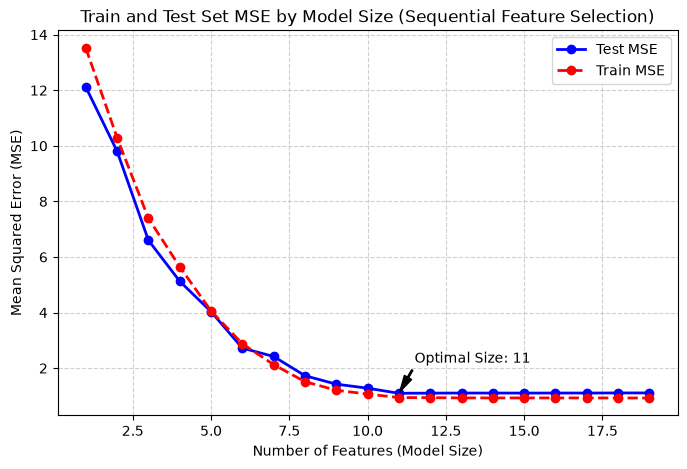

In [4]:
# 1d
plt.figure(figsize=(8, 5))
plt.plot(model_sizes, pipes['test_mse'], marker='o', linestyle='-', color='b', linewidth=2, label='Test MSE')
plt.plot(model_sizes, pipes['train_mse'], marker='o', linestyle='--', color='r', linewidth=2, label='Train MSE')

plt.title('Train and Test Set MSE by Model Size (Sequential Feature Selection)')
plt.xlabel('Number of Features (Model Size)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 1e
# Highlight the optimal model size (lowest test MSE)
best_size = model_sizes[np.argmin(pipes['test_mse'])]
best_mse = min(pipes['test_mse'])
print(f'Model size {best_size} with MSE {best_mse:.4} is the minimum MSE on the test set.')
plt.annotate(f'Optimal Size: {best_size}', 
             xy=(best_size, best_mse), 
             xytext=(best_size + 0.5, best_mse + (max(pipes['test_mse'])-min(pipes['test_mse']))*0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()

In [5]:
# 1f
best_pipeline: Pipeline = pipes['pipeline'][np.argmin(pipes['test_mse'])]
lr: LinearRegression = best_pipeline.named_steps['regressor']
sfs: SequentialFeatureSelector = best_pipeline.named_steps['sfs']

selected_mask = sfs.get_support()

beta_hat = np.zeros_like(beta, dtype=float)
beta_hat[selected_mask] = lr.coef_

compare = {
    'true': beta,
    'estimated': beta_hat,
    'selected': selected_mask
}
comp_df = pd.DataFrame(compare, index=[f'X_{i}' for i in range(len(beta))])

print(comp_df)

      true  estimated  selected
X_0    2.0   2.010178      True
X_1   -1.0  -1.168573      True
X_2    0.0   0.000000     False
X_3    0.8   0.849230      True
X_4    0.0   0.000000     False
X_5   -1.5  -1.466732      True
X_6    1.2   1.234496      True
X_7    0.0   0.000000     False
X_8    0.0   0.000000     False
X_9    0.3   0.370593      True
X_10  -0.7  -0.838337      True
X_11   0.0   0.000000     False
X_12   1.8   1.872613      True
X_13   0.0   0.000000     False
X_14   0.5   0.539317      True
X_15   0.0   0.000000     False
X_16  -1.2  -1.312011      True
X_17   0.0   0.000000     False
X_18   0.4   0.347653      True
X_19   0.0   0.000000     False


It's clear to me now that the best subset selection I performed removed all the zero value coefficients. This makes sense because the dot product of a matrix and a vector looks like this:

$$
\begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} ax + by \\ cx + dy \end{bmatrix}
$$

A zero would impact it like so:

$$
y=0\\
\begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ 0 \end{bmatrix} = \begin{bmatrix} ax \\ cx \end{bmatrix}
$$

The coefficient does not add to the model in any way.

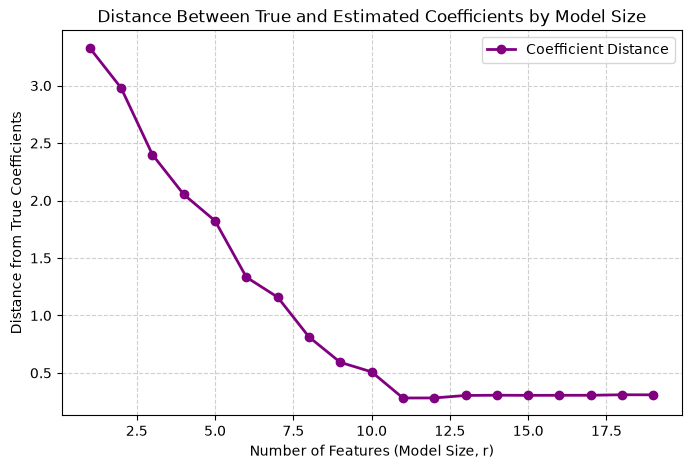

In [16]:
# 1g
def coef_distance(beta, beta_hat):
    return np.sqrt(np.sum((beta - beta_hat) ** 2))

pipes['co_est'] = []
for i in range(len(pipes['pipeline'])):

    pipe = pipes['pipeline'][i]
    lr: LinearRegression = pipe.named_steps['regressor']
    sfs: SequentialFeatureSelector = pipe.named_steps['sfs']
    selected_mask = sfs.get_support()
    beta_hat = np.zeros_like(beta, dtype=float)
    beta_hat[selected_mask] = lr.coef_

    pipes['co_est'].append(coef_distance(beta, beta_hat))

plt.figure(figsize=(8, 5))
plt.plot(model_sizes, pipes['co_est'], marker='o', linestyle='-', color='purple', linewidth=2,label='Coefficient Distance')

plt.title('Distance Between True and Estimated Coefficients by Model Size')
plt.xlabel('Number of Features (Model Size, r)')
plt.ylabel('Distance from True Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

The distance of the modeled coefficients to the true coefficients starts high and steadly decreases as the number of features approaches what I have found to be the best number of features for this model (11). After we reach the best number of features the distance slightly rebounds, but it's minimal. This is because of how the matrix-vector dot product works which I explained earlier. Before 11 features the model is missing information and cannot successfully create an accurate model. After 11 features the model has extra coefficients so the information is captured but the extra coefficients slightly perturb the distance and results.

The test MSE plot looks very similar to this one. That is because if the coefficients, or unknowns we are solving for are exactly the same as the true coefficients then the predictions will match perfectly. Therefore a distance measure of the coefficients equaling zero would also give us a MSE of zero. The magnitudes are different because MSE takes an average and the distance function takes a square root.